## NSFG pregnancy data 

Key ideas in this notebook:
- **caseid** identifies a woman, while **pregordr** tells us the order of the pregnancy for that woman.
- **outcome** records whether the pregnancy ended in a live birth, miscarriage, abortion, stillbirth, or another result.
- **birthwgt_lb** and **birthwgt_oz** are birth-weight variables; the survey sometimes uses special codes for missing or not-applicable values, which we treat as missing data.
- **agepreg** is the mother's age at pregnancy, stored in a way that needs to be converted to a more natural scale before analysis.
- **prglngth** is the length of the pregnancy in weeks, and **birthord** records the birth order of the child.

These steps are typical in exploratory data analysis: inspect the distribution of values, clean the data, and then compute meaningful summaries such as means and frequencies.

In [609]:


# without manually copying them into the workspace.
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")


In [610]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

In [611]:
%pip install statsmodels

You should consider upgrading via the '/Users/ayushthasale07/Sarg<3/EDA/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [612]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML
from thinkstats import decorate



In [613]:


try:
    import statadict
except ImportError:
    %pip install statadict



In [614]:


dct_file = "./data/2002FemPreg.dct"
dat_file = "./data/2002FemPreg.dat.gz"



In [615]:
# this function reads the NSFG data file using a Stata dictionary.
# The original data are stored in a fixed-width text format, so the .dct file tells us
# where each variable begins and ends. This is a common structure in survey data.
# We use the dictionary to attach meaningful column names to the raw data.
from statadict import parse_stata_dict


def read_stata(dct_file, dat_file):
    stata_dict = parse_stata_dict(dct_file)
    resp = pd.read_fwf(
        dat_file,
        names=stata_dict.names,
        colspecs=stata_dict.colspecs,
        compression="gzip",
    )
    return resp


In [616]:
preg = read_stata(dct_file, dat_file)

In [617]:
preg.shape

(13593, 243)

In [618]:
preg.head()

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,poverty_i,laborfor_i,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw
0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,5.0,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231


In [619]:
preg.columns

Index(['caseid', 'pregordr', 'howpreg_n', 'howpreg_p', 'moscurrp', 'nowprgdk',
       'pregend1', 'pregend2', 'nbrnaliv', 'multbrth',
       ...
       'poverty_i', 'laborfor_i', 'religion_i', 'metro_i', 'basewgt',
       'adj_mod_basewgt', 'finalwgt', 'secu_p', 'sest', 'cmintvw'],
      dtype='object', length=243)

In [620]:

def show_table(d):
    df = pd.DataFrame(d)
    return HTML(df.to_html(index=False))

In [621]:

d = {
    "Value": [1, 2, 3, 4, 5, 6, "Total"],
    "Label": [
        "LIVE BIRTH",
        "INDUCED ABORTION",
        "STILLBIRTH",
        "MISCARRIAGE",
        "ECTOPIC PREGNANCY",
        "CURRENT PREGNANCY",
        "",
    ],
    "Total": [9148, 1862, 120, 1921, 190, 352, 13593],
}

show_table(d)

Value,Label,Total
1,LIVE BIRTH,9148
2,INDUCED ABORTION,1862
3,STILLBIRTH,120
4,MISCARRIAGE,1921
5,ECTOPIC PREGNANCY,190
6,CURRENT PREGNANCY,352
Total,,13593


In [622]:
# birthwgt_lb stores birth weight in pounds.
# Before analyzing it, we inspect its distribution with value_counts().
# This is a good example of a descriptive step from ThinkStats: look at the data shape
# before deciding how to clean or summarize it.
preg["outcome"].value_counts().sort_index()

outcome
1    9148
2    1862
3     120
4    1921
5     190
6     352
Name: count, dtype: int64

In [623]:

counts = preg["birthwgt_lb"].value_counts(dropna=False).sort_index()
counts

birthwgt_lb
0.0        8
1.0       40
2.0       53
3.0       98
4.0      229
5.0      697
6.0     2223
7.0     3049
8.0     1889
9.0      623
10.0     132
11.0      26
12.0      10
13.0       3
14.0       3
15.0       1
51.0       1
97.0       1
98.0       1
99.0      57
NaN     4449
Name: count, dtype: int64

In [624]:
counts.loc[0:5]

birthwgt_lb
0.0      8
1.0     40
2.0     53
3.0     98
4.0    229
5.0    697
Name: count, dtype: int64

In [625]:

preg["birthwgt_lb"] = preg["birthwgt_lb"].replace([51, 97, 98, 99], np.nan)

In [626]:

preg["agepreg"].mean()

np.float64(2468.8151197039497)

In [627]:

preg["agepreg"] = preg["agepreg"] / 100

In [628]:

preg["agepreg"].mean()

np.float64(24.6881511970395)

In [629]:

preg["birthwgt_oz"] = preg["birthwgt_oz"].replace([97, 98, 99], np.nan)

In [630]:

preg["totalwgt_lb"] = preg["birthwgt_lb"] + preg["birthwgt_oz"] / 16.0
preg["totalwgt_lb"].mean()

np.float64(7.265628457623368)

In [631]:

weights = preg["totalwgt_lb"]
n = weights.count()
n

np.int64(9038)

In [632]:
subset = preg.query("caseid == 10229")
subset.shape

(7, 244)

In [633]:
subset["outcome"].values

array([4, 4, 4, 4, 4, 4, 1])

In [634]:
preg["birthord"].value_counts(dropna=False).sort_index()

birthord
1.0     4413
2.0     2874
3.0     1234
4.0      421
5.0      126
6.0       50
7.0       20
8.0        7
9.0        2
10.0       1
NaN     4445
Name: count, dtype: int64

In [635]:
preg["birthwgt_kg"] = preg["totalwgt_lb"] * 0.45359237

In [636]:
preg["birthwgt_kg"].mean()

np.float64(3.295633631632828)

In [637]:
ans = preg.query("caseid ==2298")

In [638]:

ans["prglngth"].values

array([40, 36, 30, 40])

In [639]:

ans2 = preg.query("caseid == 5013 and pregordr == 1")


In [640]:
ans2.birthwgt_kg

5516    3.345244
Name: birthwgt_kg, dtype: float64

In [641]:
from nsfg import read_fem_preg
preg = read_fem_preg()

In [642]:
live = preg.query("outcome == 1")

In [643]:
from empiricaldist import FreqTab

In [644]:
ftab_lb = FreqTab.from_seq(live["birthwgt_lb"], name="birthwgt_lb")

In [645]:
ftab_lb

,freqs
birthwgt_lb,
0.0,8
1.0,40
2.0,53
3.0,98
4.0,229
5.0,697
6.0,2223
7.0,3049
8.0,1889


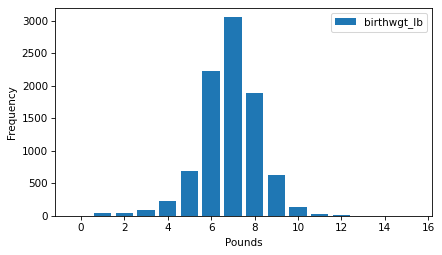

In [646]:
ftab_lb.bar()
decorate(xlabel="Pounds", ylabel="Frequency")

In [647]:
ftab_lb.mode()

np.float64(7.0)

In [648]:
ftab_age = FreqTab.from_seq(live["agepreg"], name="agepreg")

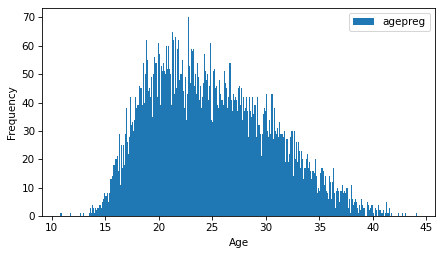

In [649]:
ftab_age.bar(width=0.1)
decorate(xlabel="Age", ylabel="Frequency")

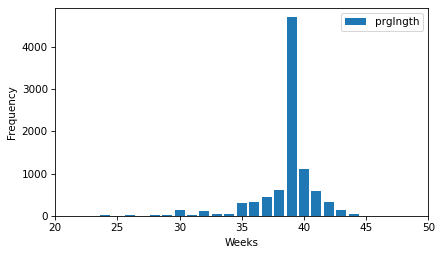

In [650]:
ftab_length = FreqTab.from_seq(live["prglngth"], name="prglngth")
ftab_length.bar()
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])

In [651]:
firsts = live.query("birthord == 1")
others = live.query("birthord != 1")

In [652]:
ftab_first = FreqTab.from_seq(firsts["prglngth"],  name="prglngth")
ftab_other = FreqTab.from_seq(others["prglngth"], name="others")

In [653]:
def two_bar_plots(ftab1, ftab2, width=0.45):
    ftab1.bar(align="edge", width=-width)
    ftab2.bar(align="edge", width=width, alpha=0.5)

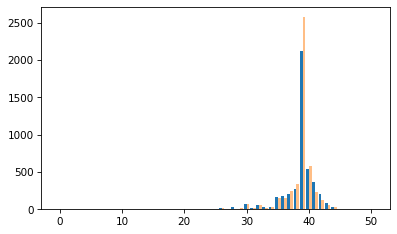

In [654]:
two_bar_plots(ftab_first, ftab_other)

In [655]:
firsts["prglngth"].count(), others["prglngth"].count()

(np.int64(4413), np.int64(4735))

In [656]:
first_mean = firsts["prglngth"].mean()
other_mean = others["prglngth"].mean()
first_mean, other_mean

(np.float64(38.60095173351461), np.float64(38.52291446673706))

In [657]:
# Effect Size

diff = first_mean - other_mean
# diff = diff * 7 * 24
diff / live["prglngth"].mean() * 100

np.float64(0.20237586646738304)

In [658]:
group1, group2 = firsts["prglngth"], others["prglngth"]
v1, v2 = group1.var(), group2.var()

In [659]:
n1, n2 = group1.count(), group2.count()
pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)

In [660]:
np.sqrt(pooled_var)

np.float64(2.7022108144953862)

In [661]:
firsts["prglngth"].std(), others["prglngth"].std()

(np.float64(2.7919014146687204), np.float64(2.6158523504392375))

In [662]:
def cohen_effect(group1, group2):
    """Computes Cohen's d effect size for two groups."""
    diff = group1.mean() - group2.mean()
    v1, v2 = group1.var(), group2.var()
    n1, n2 = group1.count(), group2.count()
    pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)
    return diff / np.sqrt(pooled_var)

In [663]:
cohen_effect(firsts["prglngth"], others["prglngth"])

np.float64(0.028879044654449834)

In [664]:
from nsfg import read_fem_resp
resp = read_fem_resp()
resp.shape

(7643, 3092)

In [665]:
ftab_income = FreqTab.from_seq(resp["totincr"], name="totincr")

In [666]:
resp["totincr"].value_counts(dropna=False).sort_index()

totincr
1      299
2      301
3      266
4      421
5      445
6      559
7      583
8      606
9      607
10     468
11     647
12     658
13     623
14    1160
Name: count, dtype: int64

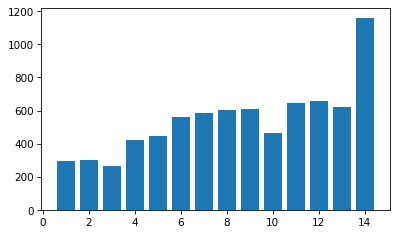

In [667]:
ftab_income.bar()

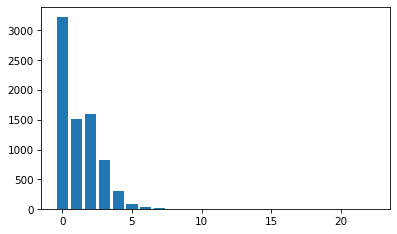

In [668]:
ftab_parity = FreqTab.from_seq(resp["parity"], name="parity")
ftab_parity.bar()

In [669]:
resp["parity"].nlargest(20)

715     22
5339    16
682     10
3053    10
5338    10
2444     9
3141     9
933      8
1669     8
1871     8
2315     8
2445     8
3266     8
7037     8
7146     8
182      7
315      7
1251     7
1289     7
1860     7
Name: parity, dtype: int64

In [670]:
resp.loc[715]

caseid              7263
rscrinf                1
rdormres               5
rostscrn               8
rscreenhisp            1
                 ...    
agemarry             NaN
age            39.416667
year                  62
decade                 6
fives                 12
Name: 715, Length: 3092, dtype: object

In [671]:
resp.head()

,caseid,rscrinf,rdormres,rostscrn,rscreenhisp,rscreenrace,age_a,age_r,cmbirth,agescrn,...,sest,cmintvw,cmlstyr,screentime,intvlngth,agemarry,age,year,decade,fives
0,2298,1,5,5,1,5.0,27,27,902,27,...,18,1234,1222,18:26:36,110.492667,NaN,27.666667,75,7,15
1,5012,1,5,1,5,5.0,42,42,718,42,...,18,1233,1221,16:30:59,64.294000,21.333333,42.916667,59,5,11
2,11586,1,5,1,5,5.0,43,43,708,43,...,18,1234,1222,18:19:09,75.149167,16.833333,43.833333,58,5,11
3,6794,5,5,4,1,5.0,15,15,1042,15,...,18,1234,1222,15:54:43,28.642833,NaN,16.000000,86,8,17
4,616,1,5,4,1,5.0,20,20,991,20,...,18,1233,1221,14:19:44,69.502667,NaN,20.166667,82,8,16


In [672]:
high_inc = resp.query("totincr >= 14")
ftab_inc = FreqTab.from_seq(high_inc["parity"], name="parity")

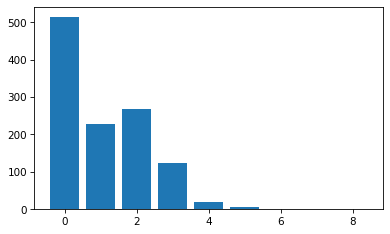

In [673]:
ftab_inc.bar()

In [674]:
high_inc["parity"].mean()

np.float64(1.0758620689655172)

In [675]:
lower_inc = resp.query("totincr < 14")

In [676]:
lower_inc["parity"].mean()

np.float64(1.2495758136665125)

In [677]:
cohen_effect(high_inc["parity"], lower_inc["parity"])

np.float64(-0.12511855314660367)

In [678]:
from empiricaldist import Pmf

In [679]:
ranges = pd.interval_range(start=5, end=50, freq=5, closed="left")
ranges.name = "class size"

In [680]:
data = pd.DataFrame(index=ranges)
data["count"] = [8, 8, 14, 4, 6, 12, 8, 3, 2]
data

,count
class size,
"[5, 10)",8
"[10, 15)",8
"[15, 20)",14
"[20, 25)",4
"[25, 30)",6
"[30, 35)",12
"[35, 40)",8
"[40, 45)",3
"[45, 50)",2


In [681]:
sizes = ranges.left + 2

In [682]:
counts = data["count"]
actual_pmf = Pmf(counts, sizes, name="actual")
actual_pmf.normalize()

np.int64(65)

In [683]:
actual_pmf

,probs
7,0.123077
12,0.123077
17,0.215385
22,0.061538
27,0.092308
32,0.184615
37,0.123077
42,0.046154
47,0.030769


In [684]:
def bias(pmf, name):
# multiply each probability by class size
    ps = pmf.ps * pmf.qs
    # make a new Pmf and normalize it
    new_pmf = Pmf(ps, pmf.qs, name=name)
    new_pmf.normalize()
    return new_pmf

In [685]:
observed_pmf = bias(actual_pmf, name="observed")

In [686]:
observed_pmf.normalize()

np.float64(1.0)

In [687]:
data["count"]

class size
[5, 10)      8
[10, 15)     8
[15, 20)    14
[20, 25)     4
[25, 30)     6
[30, 35)    12
[35, 40)     8
[40, 45)     3
[45, 50)     2
Name: count, dtype: int64

In [688]:
actual_pmf.ps * actual_pmf.qs

array([0.86153846, 1.47692308, 3.66153846, 1.35384615, 2.49230769,
       5.90769231, 4.55384615, 1.93846154, 1.44615385])

In [689]:
actual_pmf.qs

array([ 7, 12, 17, 22, 27, 32, 37, 42, 47])

In [690]:
actual_pmf.qs[0]

np.int64(7)

In [691]:
print(f"actual_pmf: {actual_pmf}, observed_pmf: {observed_pmf}")

actual_pmf: 7     0.123077
12    0.123077
17    0.215385
22    0.061538
27    0.092308
32    0.184615
37    0.123077
42    0.046154
47    0.030769
Name: actual, dtype: float64, observed_pmf: 7     0.036364
12    0.062338
17    0.154545
22    0.057143
27    0.105195
32    0.249351
37    0.192208
42    0.081818
47    0.061039
Name: observed, dtype: float64


In [692]:
def unbias(pmf, name):
# divide each probability by class size
    ps = pmf.ps / pmf.qs
    new_pmf = Pmf(ps, pmf.qs, name=name)
    new_pmf.normalize()
    return new_pmf

In [693]:
from nsfg import get_nsfg_groups
live, firsts, others = get_nsfg_groups()

In [694]:
first_pmf = Pmf.from_seq(firsts["prglngth"], name="firsts")
other_pmf = Pmf.from_seq(others["prglngth"], name="others")

In [695]:
from nsfg import read_fem_resp
resp = read_fem_resp()
resp.shape

(7643, 3092)

In [696]:
resp = resp.query("numbabes < 10")

In [697]:
num_bb = resp["numbabes"]

In [698]:
ftab_bb = FreqTab.from_seq(num_bb, name="numbabes")

In [699]:
ftab_bb

,freqs
numbabes,
0,3229
1,1519
2,1603
3,828
4,309
5,95
6,29
7,15
8,8


In [700]:
bb_pmf = Pmf.from_seq(num_bb, name="numbabes")
bb_pmf

,probs
numbabes,
0,0.422810
1,0.198900
2,0.209899
3,0.108420
4,0.040461
5,0.012439
6,0.003797
7,0.001964
8,0.001048


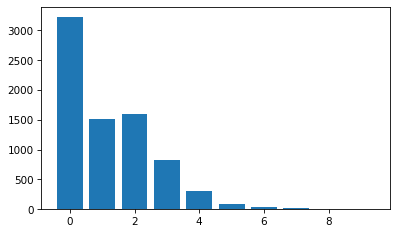

In [701]:
ftab_bb.bar()

In [702]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/relay.py")
download(
    "https://github.com/AllenDowney/ThinkStats/raw/v3/data/Apr25_27thAn_set1.shtml"
)


In [703]:
from relay import read_results
results = read_results()
results.head() 

,Place,Div/Tot,Division,Guntime,Nettime,Min/Mile,MPH
0,1,1/362,M2039,30:43,30:42,4:57,12.121212
1,2,2/362,M2039,31:36,31:36,5:06,11.764706
2,3,3/362,M2039,31:42,31:42,5:07,11.726384
3,4,4/362,M2039,32:28,32:27,5:14,11.464968
4,5,5/362,M2039,32:52,32:52,5:18,11.320755


In [704]:
speeds = results["MPH"].values

In [705]:
speeds

array([12.12121212, 11.76470588, 11.72638436, ...,  3.27868852,
        3.22580645,  3.06122449])

In [706]:
my_res = results.query("Nettime == '42:44'")
my_res

,Place,Div/Tot,Division,Guntime,Nettime,Min/Mile,MPH
96,97,26/256,M4049,42:48,42:44,6:53,8.716707


In [707]:
my_speed = speeds[96]

In [708]:
(speeds<=my_speed).sum()

np.int64(1537)

In [709]:
def percentile_rank(x, seq):
    count = (seq <= x).mean()
    return count  * 100
percentile_rank(my_speed, speeds)

np.float64(94.12124923453766)

In [710]:
my_div = results.query("Division == 'M4049'")

In [711]:
my_div_speeds = my_div["MPH"].values

In [712]:
percentile_rank(my_speed, my_div["MPH"].values)

np.float64(90.234375)

In [713]:
def percentile(p, seq):
    n = len(seq)
    i = (1 - p / 100) * (n + 1)
    return seq[round(i)]

In [714]:
percentile(90, my_div_speeds)

np.float64(8.591885441527447)

In [715]:
next_division = results.query("Division == 'M5059'")
next_division_speeds = next_division["MPH"].values
percentile(90.2, next_division_speeds)

np.float64(8.017817371937639)

In [716]:
from empiricaldist import Cdf
cdf_speeds = Cdf.from_seq(speeds, name="speeds")

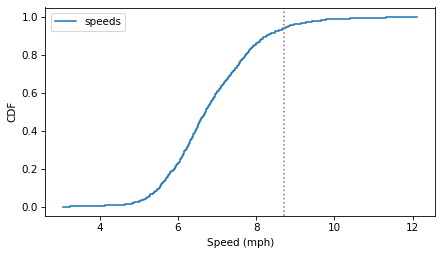

In [717]:
cdf_speeds.step()
plt.axvline(my_speed, ls=":", color="gray")
decorate(xlabel="Speed (mph)", ylabel="CDF")

In [718]:
speeds

array([12.12121212, 11.76470588, 11.72638436, ...,  3.27868852,
        3.22580645,  3.06122449])

In [719]:
cdf_speeds

,probs
3.061224,0.000612
3.225806,0.001225
3.278689,0.002449
3.383459,0.003062
4.031355,0.003674
...,...
11.320755,0.997551
11.464968,0.998163
11.726384,0.998775
11.764706,0.999388


In [720]:
cdf_speeds.inverse(0.5)

array(6.70391061)

In [721]:
from nsfg import get_nsfg_groups
live, firsts, others = get_nsfg_groups()

In [722]:
first_weights = firsts["totalwgt_lb"].dropna()
first_weights.mean()

np.float64(7.201094430437772)

In [723]:
other_weights = others["totalwgt_lb"].dropna()
other_weights.mean()

np.float64(7.325855614973262)

In [724]:
first_pmf = Pmf.from_seq(first_weights, name="firsts")
other_pmf = Pmf.from_seq(other_weights, name="others")

In [725]:
first_pmf

,probs
totalwgt_lb,
0.1250,0.000229
0.3125,0.000229
0.4375,0.000229
0.6250,0.000229
0.9375,0.000229
...,...
12.3750,0.000458
12.5000,0.000229
13.7500,0.000229


In [726]:
first_cdf = first_pmf.make_cdf()
other_cdf = other_pmf.make_cdf()

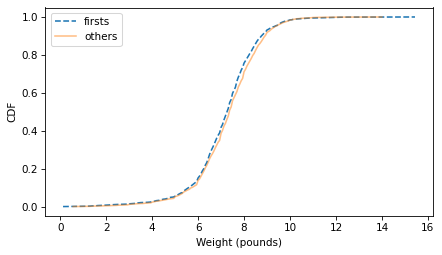

In [727]:
first_cdf.plot(ls="--")
other_cdf.plot(alpha=0.5)
decorate(xlabel="Weight (pounds)", ylabel="CDF")

In [728]:
def median(cdf):
    m = cdf.inverse(0.5)
    return m

In [729]:
def iqr(cdf):
    low, high = cdf.inverse([0.25, 0.75])
    return high - low

In [730]:
def quartile_skewness(cdf):
    low, median, high = cdf.inverse([0.25, 0.5, 0.75])
    midpoint = (high + low) / 2
    semi_iqr = (high - low) / 2
    return (midpoint - median) / semi_iqr

In [731]:
from nsfg import get_nsfg_groups
live, firsts, others = get_nsfg_groups()

In [732]:
firsts["totalwgt_lb"]

0        8.8125
2        9.1250
5        8.5625
8        7.5625
10       7.8125
          ...  
13576    6.4375
13578    6.0000
13581    6.3750
13584    6.3750
13588    6.1875
Name: totalwgt_lb, Length: 4413, dtype: float64

In [733]:
firsts_seq = FreqTab.from_seq(firsts["totalwgt_lb"], name="firsts")
firsts_seq

,freqs
totalwgt_lb,
0.1250,1
0.3125,1
0.4375,1
0.6250,1
0.9375,1
...,...
12.3750,2
12.5000,1
13.7500,1


In [734]:
cdf_fb_weights = Cdf.from_seq(firsts["totalwgt_lb"], name="First Babies Weights")

In [735]:
cdf_fb_weights[8.5] * 100

np.float64(85.90419436167774)

In [736]:
male = live.query("babysex == 1")
female = live.query("babysex == 2")

In [737]:
male_cdf = Cdf.from_seq(male["totalwgt_lb"], name="male")
female_cdf = Cdf.from_seq(female["totalwgt_lb"], name="female")

In [738]:
male_cdf

,probs
totalwgt_lb,
0.3125,0.000218
0.4375,0.000436
0.9375,0.000654
1.0000,0.000872
1.0625,0.001309
...,...
12.0000,0.998909
12.3750,0.999128
12.5000,0.999346


<Axes: xlabel='totalwgt_lb'>

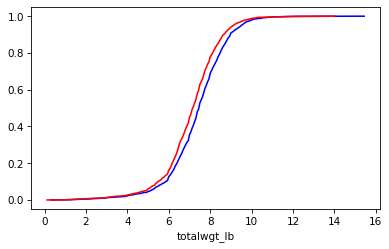

In [739]:
male_cdf.plot(color="blue", label="male")
female_cdf.plot(color="red", label="female")

In [740]:
male_cdf[8.5] * 100

np.float64(80.65430752453653)

In [741]:
female_cdf[8.5] * 100

np.float64(87.58140579384684)

In [742]:
from nsfg import read_fem_preg
preg = read_fem_preg()

In [743]:
twenty = preg.query("agepreg <= 20")
thirty = preg.query("agepreg <= 30")
twenty = twenty.dropna(subset=["agepreg"])
thirty = thirty.dropna(subset=["agepreg"])
preg = preg.dropna(subset=["agepreg"])

In [744]:
cdf_twenty = Cdf.from_seq(twenty["agepreg"], name="twenty")
cdf_thirty = Cdf.from_seq(thirty["agepreg"], name="thirty")

In [745]:
cdf_overall = Cdf.from_seq(preg["agepreg"], name="overall")

In [746]:
cdf_overall[30] - cdf_overall[20]

np.float64(0.5574352390302847)

In [747]:
speeds = results["MPH"].values

In [748]:
cdf_speeds = Cdf.from_seq(speeds, name="speeds")

In [749]:
cdf_speeds

,probs
3.061224,0.000612
3.225806,0.001225
3.278689,0.002449
3.383459,0.003062
4.031355,0.003674
...,...
11.320755,0.997551
11.464968,0.998163
11.726384,0.998775
11.764706,0.999388


In [750]:
cdf_speeds.inverse(0.5)

array(6.70391061)

In [751]:
iqr_speeds = cdf_speeds.inverse(0.75) - cdf_speeds.inverse(0.25)

In [752]:
iqr_speeds

np.float64(1.4865637507146943)

In [753]:
def qu_sk(cdf):
    low, median, high = cdf.inverse([0.25, 0.5, 0.75])
    midpoint = (high + low) / 2
    semi_iqr = (high - low) / 2
    return (midpoint - median) / semi_iqr

In [754]:
qu_sk(cdf_speeds)

np.float64(0.13450795015040942)

In [755]:
def flip(n, p):
    choices = [1, 0]
    probs = [p, 1 - p]
    return np.random.choice(choices, n, p=probs)

In [756]:
np.random.choice([1, 0], 10, p=[0.3, 0.7])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [757]:
def simulate_round(n, p):
    pts = flip(n, p)
    return pts.sum()

In [758]:
n = 25
p = 0.9
results_sim = [simulate_round(n, p) for i in range(1000)]

In [759]:
results_sim[:10]

[np.int64(23),
 np.int64(25),
 np.int64(22),
 np.int64(23),
 np.int64(21),
 np.int64(24),
 np.int64(22),
 np.int64(24),
 np.int64(23),
 np.int64(22)]

In [760]:
pmf_sim = Pmf.from_seq(results_sim, name="simulated")

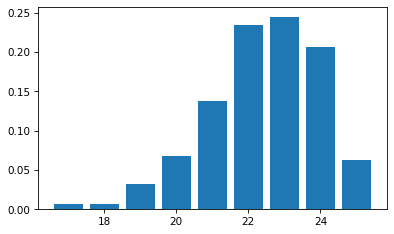

In [761]:
pmf_sim.bar()

In [762]:
from scipy.special import comb
def binomial_pmf(k, n, p):
    return comb(n, k) * (p**k) * ((1 - p) ** (n - k))   

In [763]:
filename = "Shooting_at_the_2020_Summer_Olympics_Mens_skeet"

In [764]:
!pip install lxml

You should consider upgrading via the '/Users/ayushthasale07/Sarg<3/EDA/.venv/bin/python3 -m pip install --upgrade pip' command.


In [765]:
tables = pd.read_html(filename)
table = tables[6]
table.head()


,Rank,Athlete,Country,1,2,3,4,5,Total[3],Shoot-off,Notes
0,1,Éric Delaunay,France,25,25,25,24,25,124,+6,"Q, OR"
1,2,Tammaro Cassandro,Italy,24,25,25,25,25,124,+5,"Q, OR"
2,3,Eetu Kallioinen,Finland,25,25,24,25,24,123,NaN,Q
3,4,Vincent Hancock,United States,25,25,25,25,22,122,+8,Q
4,5,Abdullah Al-Rashidi,Kuwait,25,25,24,25,23,122,+7,Q


In [766]:
len(table)

30

In [767]:
columns = ["1", "2", "3", "4", "5"]
results = table[columns].values.flatten()

In [768]:
results

array([25, 25, 25, 24, 25, 24, 25, 25, 25, 25, 25, 25, 24, 25, 24, 25, 25,
       25, 25, 22, 25, 25, 24, 25, 23, 25, 24, 23, 25, 25, 24, 25, 25, 25,
       23, 24, 24, 25, 25, 24, 25, 24, 24, 25, 24, 23, 25, 24, 24, 25, 23,
       25, 24, 24, 25, 24, 25, 24, 23, 25, 24, 25, 24, 24, 24, 25, 24, 25,
       23, 24, 24, 24, 23, 24, 25, 24, 24, 23, 24, 25, 25, 23, 25, 23, 24,
       24, 25, 24, 23, 24, 23, 22, 22, 24, 23, 23, 24, 23, 24, 25, 25, 25,
       23, 22, 24, 24, 24, 23, 25, 23, 25, 24, 23, 24, 23, 24, 23, 23, 23,
       24, 25, 24, 22, 23, 23, 25, 23, 23, 22, 23, 23, 23, 23, 22, 23, 23,
       25, 23, 24, 19, 23, 22, 22, 25, 20, 21, 22, 22, 23, 19])

In [769]:
total_shots = 25 * len(results)
total_hits = results.sum()
n, total_shots, total_hits

(25, 3750, np.int64(3575))

In [770]:
p = total_hits / total_shots
p

np.float64(0.9533333333333334)

In [771]:
ks = np.arange(16, n + 1)
ps = binomial_pmf(ks, n, p)
pmf_binom = Pmf(ps, ks, name="binomial model")

In [772]:
ps = binomial_pmf(ks, n, p)
pmf_binom = Pmf(ps, ks, name="binomial model")

In [773]:
ps.shape

(10,)

In [774]:
n = 3600
m = 6
p = m / 3600
p

0.0016666666666666668

In [775]:
def simulate_goals(n, p):
    return flip(n, p).sum()

In [776]:
goals = [simulate_goals(n, p) for i in range(1001)]
np.mean(goals)

np.float64(5.9480519480519485)

In [777]:
goals[:10]

[np.int64(3),
 np.int64(8),
 np.int64(5),
 np.int64(5),
 np.int64(3),
 np.int64(7),
 np.int64(8),
 np.int64(7),
 np.int64(3),
 np.int64(5)]

In [778]:
from scipy.special import factorial
def poisson_pmf(k, lam):
    return (lam**k) * np.exp(-lam) / factorial(k)

In [779]:
lam = 6
ks = np.arange(20)
ps = poisson_pmf(ks, lam)
pmf_poisson = Pmf(ps, ks, name="Poisson model")

In [780]:
ps, ks


(array([2.47875218e-03, 1.48725131e-02, 4.46175392e-02, 8.92350784e-02,
        1.33852618e-01, 1.60623141e-01, 1.60623141e-01, 1.37676978e-01,
        1.03257734e-01, 6.88384890e-02, 4.13030934e-02, 2.25289600e-02,
        1.12644800e-02, 5.19899078e-03, 2.22813891e-03, 8.91255562e-04,
        3.34220836e-04, 1.17960295e-04, 3.93200983e-05, 1.24168732e-05]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]))

In [781]:
pmf_poisson.mean()

np.float64(5.999894417747437)

In [782]:
n = 3600
m = 6
p = m / 3600
p


0.0016666666666666668

In [783]:
def simulate_first_goal(n, p):
    return flip(n, p).argmax()

In [784]:
first_goal_times = [simulate_first_goal(n, p) for i in range(1001)]
mean = np.mean(first_goal_times)
mean

np.float64(600.3616383616384)

In [785]:
def exponential_cdf(x, lam):
    return 1 - np.exp(-lam * x)

In [786]:
lam = 1 / mean
lam

np.float64(0.0016656627207710304)

In [787]:
from empiricaldist import Cdf
ts = np.linspace(0, 3600, 201)
ps = exponential_cdf(ts, lam)
cdf_expo = Cdf(ps, ts, name="exponential model")

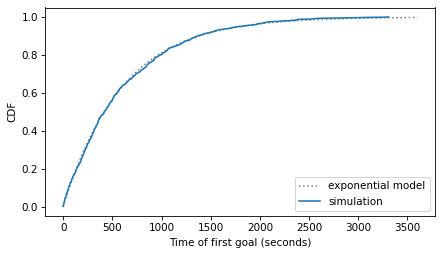

In [788]:
cdf_sim = Cdf.from_seq(first_goal_times, name="simulation")
cdf_expo.plot(ls=":", color="gray")
cdf_sim.plot()
decorate(xlabel="Time of first goal (seconds)", ylabel="CDF")

In [789]:
def simulate_growth(n):
    choices = [1, 2, 3]
    gains = np.random.choice(choices, n)
    return gains.sum()

In [790]:
sim_weights = [simulate_growth(100) for i in range(1001)]
m, s = np.mean(sim_weights), np.std(sim_weights)
m, s

(np.float64(200.01198801198802), np.float64(8.352131347495101))

In [791]:
choices = [1, 2, 3]
np.random.choice(choices, 10)

array([1, 3, 2, 1, 3, 3, 1, 1, 3, 1])

In [792]:
from scipy.stats import norm
def make_normal_model(data):
    m, s = np.mean(data), np.std(data)
    low, high = m - 4 * s, m + 4 * s
    qs = np.linspace(low, high, 201)
    ps = norm.cdf(qs, m, s)
    return Cdf(ps, qs, name="normal model")

In [793]:
ps = norm.cdf([3, 7, 11, 15, 19], 11, 5.657)
ps

array([0.07865495, 0.23975572, 0.5       , 0.76024428, 0.92134505])

In [794]:
data = [3, 7, 11, 15, 19]
make_normal_model(data)

,probs
-11.627417,0.000032
-11.401143,0.000037
-11.174869,0.000044
-10.948594,0.000052
-10.722320,0.000062
...,...
32.722320,0.999938
32.948594,0.999948
33.174869,0.999956
33.401143,0.999963


In [795]:
cdf_model = make_normal_model(sim_weights)

In [796]:
cdf_sim_weights = Cdf.from_seq(sim_weights, name="simulation")

In [797]:
import nsfg
preg = nsfg.read_fem_preg()
birth_weights = preg["totalwgt_lb"].dropna()

In [798]:
m, s = np.mean(birth_weights), np.std(birth_weights)
m, s

(np.float64(7.265628457623368), np.float64(1.40821553384062))

In [799]:
from scipy.stats import trimboth
trimmed = trimboth(birth_weights, 0.01)
m, s = np.mean(trimmed), np.std(trimmed)
m, s

(np.float64(7.280883100022579), np.float64(1.2430657948614345))

In [800]:
cdf_model = make_normal_model(trimmed)

In [801]:
cdf_birth_weight = Cdf.from_seq(birth_weights, name='data')
# two_cdf_plots(cdf_model, cdf_birth_weight, xlabel="Birth weight (pounds)")

In [802]:
def simulate_proportionate_growth(n):
    choices = [1.03, 1.05, 1.07]
    gains = np.random.choice(choices, n)
    return gains.prod()

In [803]:
sim_weights = [simulate_proportionate_growth(100) for i in range(1001)]
np.mean(sim_weights), np.std(sim_weights)

(np.float64(130.9474587446382), np.float64(19.409175725335125))

In [804]:
log_sim_weights = np.log10(sim_weights)
m, s = np.mean(log_sim_weights), np.std(log_sim_weights)
m, s

(np.float64(2.1123610313752352), np.float64(0.06418817872083837))

In [805]:
cdf_model = make_normal_model(log_sim_weights)
cdf_log_sim_weights = Cdf.from_seq(log_sim_weights, name="simulation")

In [806]:
from nsfg import read_fem_resp
resp = read_fem_resp()

In [807]:
older = resp.query("age >= 25")
num_family = older["numfmhh"]

In [808]:
num_family[:10]

0     4
1     1
2     0
5     3
8     3
10    2
11    2
13    3
14    1
15    3
Name: numfmhh, dtype: int64

In [809]:
num_fam_pmf = Pmf.from_seq(num_family, name="numfmhh")

In [823]:
num_fam_pmf.ps

array([0.11833398, 0.22927209, 0.23958739, 0.23160763, 0.12047489,
       0.03950954, 0.01342935, 0.00778513])

In [811]:
# def poisson_pmf(k, lam):
#     return (lam**k) * np.exp(-lam) / factorial(k)
# lam = 6
# ks = np.arange(20)
# ps = poisson_pmf(ks, lam)
# pmf_poisson = Pmf(ps, ks, name="Poisson model")

In [826]:
ks = np.arange(0,8)
lam = num_family.mean()
ps = poisson_pmf(ks, lam)

In [827]:
ks

array([0, 1, 2, 3, 4, 5, 6, 7])

In [828]:
ps

array([0.10884951, 0.24140524, 0.26769295, 0.19789549, 0.10972261,
       0.04866832, 0.01798934, 0.00569951])

In [830]:
num_fam_pmf.ps - ps

array([ 0.00948448, -0.01213315, -0.02810556,  0.03371214,  0.01075228,
       -0.00915878, -0.00455999,  0.00208562])

In [831]:
lam

np.float64(2.2177890229661346)

In [832]:
from thinkstats import two_cdf_plots

In [ ]:
def normal_pdf(xs, mu, sigma):
    z = (xs - mu) / sigma
    return np.exp(-(z**2) / 2) / sigma / np.sqrt(2 * np.pi)

In [836]:
m, s = np.mean(trimmed), np.std(trimmed)

In [837]:
low = m - 4 * s
high = m + 4 * s
qs = np.linspace(low, high, 201)
ps = normal_pdf(qs, m, s)

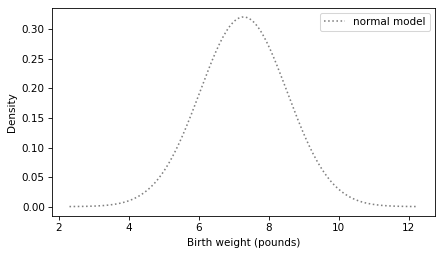

In [838]:
plt.plot(qs, ps, label="normal model", ls=":", color="gray")
decorate(xlabel="Birth weight (pounds)", ylabel="Density")

In [839]:
normal_pdf(m, m, s)

np.float64(0.32093416297880123)

In [840]:
from thinkstats import NormalPdf
pdf_model = NormalPdf(m, s, name="normal model")
pdf_model

NormalPdf(7.280883100022579, 1.2430657948614345, name='normal model')

In [841]:
pdf_model(m)

np.float64(0.32093416297880123)

In [842]:
from scipy.integrate import simpson
def area_under(pdf, low, high):
    qs = np.linspace(low, high, 501)
    ps = pdf(qs)
    return simpson(y=ps, x=qs)

In [843]:
area_under(pdf_model, 2, 12)

np.float64(0.9999158086616793)

In [844]:
area_under(pdf_model, 0, 8.5)

np.float64(0.8366380335513807)

In [845]:
from scipy.stats import norm
norm.cdf(8.5, m, s)

np.float64(0.8366380358092718)

In [846]:
area_under(pdf_model, 6, 8)

np.float64(0.5671317752927691)